In [1]:
# Load the CSV and check its size (2,132 × 2,548 → more features than samples, so PCA is needed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/emotions.csv')

print("Shape:", df.shape) 
df.head()

Shape: (2132, 2549)


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [2]:
# Check missing values and data types (missing values would break the model; found 0 → no extra handling needed)
print("Missing values:", df.isnull().sum().sum())
print()
print(df.dtypes.value_counts())

Missing values: 0

float64    2548
object        1
Name: count, dtype: int64


label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64


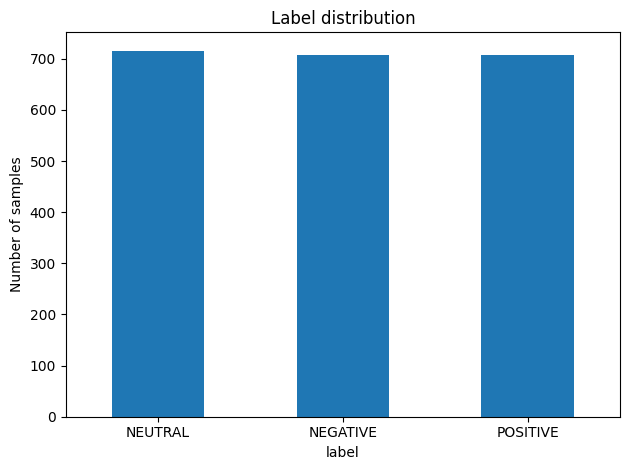

In [3]:
# Label distribution (if one class dominates, accuracy is misleading; classes are ~33% each → accuracy is fair, use stratify)
counts = df['label'].value_counts()
print(counts)

counts.plot(kind='bar')
plt.title('Label distribution')
plt.ylabel('Number of samples')
plt.xticks(rotation=0)
plt.tight_layout() 
plt.savefig('../images/label_distribution.png', dpi=150)
plt.show() 

In [4]:
# Group features by name prefix
feature_cols = df.columns.drop('label')

groups = (feature_cols
          .str.replace('#', '') 
          .str.strip() 
          .str.replace(r'\d.*$', '', regex=True) 
          .str.rstrip('_')) 

print(groups.value_counts())

fft          1500
covmat        288
logm          156
correlate     150
mean_d        110
min_q         100
max_q         100
moments        40
eigen          24
entropy        10
mean           10
min_d          10
max_d          10
max            10
stddev_d       10
stddev         10
min            10
Name: count, dtype: int64


Before: min -1580000000000000.0 / max 2.61e+18
After: min -34.996201241949564 / max 42.405881895227424


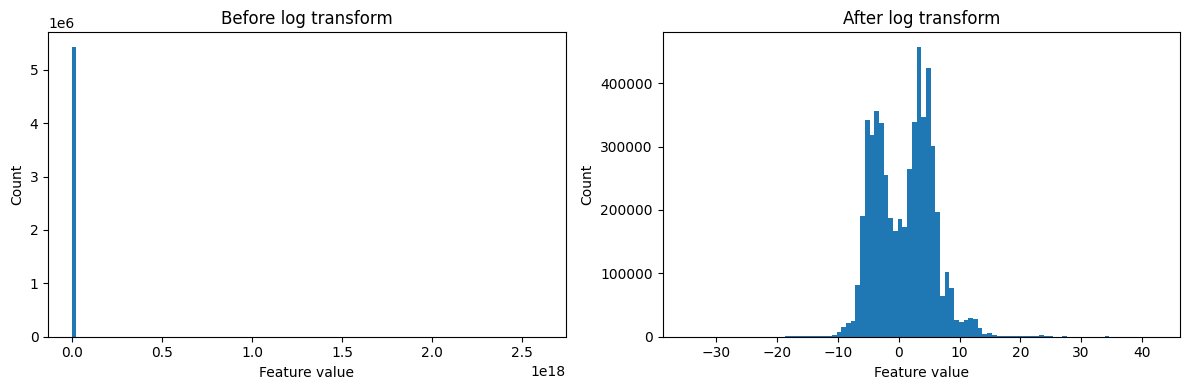

In [5]:
# Compare distributions before/after log transform (scaling)
import sys
sys.path.append('..')
from features import log_transform

x = df[feature_cols]
x_log = log_transform(x)

print("Before: min", x.values.min(), "/ max", x.values.max())
print("After: min", x_log.values.min(), "/ max", x_log.values.max())

fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes[0].hist(x.values.ravel(), bins=100)
axes[0].set_title('Before log transform')
axes[1].hist(x_log.values.ravel(), bins=100)
axes[1].set_title('After log transform')
for ax in axes:
    ax.set_xlabel('Feature value')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../images/log_transform.png', dpi=150)
plt.show()

In [6]:
# Find which feature group the extreme values come from
abs_max = x.abs().max()
print(abs_max.groupby(groups.values).max().sort_values(ascending=False))

moments      2.610000e+18
correlate    2.000000e+06
eigen        1.240000e+06
covmat       1.040000e+06
fft          2.610000e+03
min_q        2.190000e+03
max_q        2.160000e+03
max_d        2.120000e+03
mean_d       1.960000e+03
max          1.360000e+03
min_d        1.300000e+03
min          1.210000e+03
mean         9.700000e+02
stddev       9.240000e+02
stddev_d     8.600000e+02
logm         3.190000e+01
entropy      5.010000e+00
dtype: float64
